# MAB Architecture Notebook — IV.POS.7 (Pro Round 2)

Companion to `MAB_ARCHITECTURE_REPORT_FOR_PRO_R2.md`. All computation delegates to
`a4/runs/iv_pos_7/analysis/` — no inline metric logic.

**Variants:** V1–V5 × 10 seeds × N=6000. **Protagonist:** V5 (`cTS_semantic_v2`).


## Phase 9.1 — Setup


In [1]:

import sys
from pathlib import Path
import matplotlib
matplotlib.use('Agg')  # headless-safe; figures embedded via IPython.display below
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import Image, display

REPO = Path('/root/arguzz')
IV7 = REPO / 'a4/runs/iv_pos_7'
sys.path.insert(0, str(IV7))

from analysis.metrics import compute_metrics_frame, aggregate_by_variant, N_MUTATIONS
from analysis.stats import paired_tests
from analysis.success_criteria import evaluate_success_criteria
from analysis.counterfactuals import counterfactual_kind_summary, counterfactual_by_kind_frame, instr_type_mod_ranking_check
from analysis.per_arm_diagnostic import per_arm_diagnostic_frame, v5_mode_summary
from analysis.discovery_rate import discovery_rate_summary, discovery_rate_by_kind_frame
from analysis.per_loc_v2 import per_loc_v2_summary, per_loc_v2_cells_frame
from analysis.discover import discover_dbs, VARIANT_TO_PRO_NAME

PLOTS = IV7 / 'plots'
PLOTS.mkdir(exist_ok=True)
VARIANTS = ['V1', 'V2', 'V3', 'V4', 'V5']
COLORS = {'V1': '#2ca02c', 'V2': '#d62728', 'V3': '#ff7f0e', 'V4': '#9467bd', 'V5': '#1f77b4'}

def show_plot(fig, path):
    """Save PNG to plots/ and embed inline in HTML (works with Agg + nbconvert)."""
    fig.savefig(path, dpi=120, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(path)))

metrics = pd.read_csv(IV7 / 'metrics_table.csv')
agg = pd.read_csv(IV7 / 'metrics_aggregate.csv')
paired = pd.read_csv(IV7 / 'paired_tests.csv')
success = pd.read_csv(IV7 / 'success_criteria.csv')
dr = pd.read_csv(IV7 / 'discovery_rate_by_kind.csv')
ploc = pd.read_csv(IV7 / 'per_loc_v2_cells.csv')
print(metrics.groupby('variant').size())


variant
V1    10
V2    10
V3    10
V4    10
V5    10
dtype: int64


## Phase 9.1 — Headline coverage table


In [2]:

print(agg[['variant','local_context_final_mean','local_context_final_std',
           'local_coverage_v2_final_mean','local_context_AUC_mean','all_46_hit_rate',
           'allocation_entropy_by_zone_mean','novel_locs_union_vs_v1']].to_string(index=False))


variant  local_context_final_mean  local_context_final_std  local_coverage_v2_final_mean  local_context_AUC_mean  all_46_hit_rate  allocation_entropy_by_zone_mean  novel_locs_union_vs_v1
     V1                      42.9                 1.197219                         565.6               228142.30              0.0                         2.201806                       0
     V2                      31.8                 1.619328                         283.7               177804.00              0.0                         2.086905                       0
     V3                      42.1                 1.728840                         737.8               233650.35              0.0                         2.196453                       3
     V4                      41.9                 2.131770                         748.2               235617.70              0.0                         2.175506                       0
     V5                      46.4                 0.699206       

## ★ Smoking gun — V5 novel contexts vs V1 union (Criterion 5)


In [3]:

import json
novel = json.loads((IV7 / 'v5_novel_contexts.json').read_text())
print(f"V1 union: {novel['v1_union_size']} constraint_locs")
print(f"V5 union: {novel['v5_union_size']} constraint_locs")
print("Novel in V5 never hit by any V1 seed:")
for loc in novel['novel_locs_union_vs_v1']:
    print(f"  + {loc}")
print()
print("Footnote: V3 also found 3 novel locs vs V1 union:")
print("  ControlLoadRootAndNonce@inst_control.zir:35")
print("  ControlLoadRootAndNonce@inst_control.zir:36  ← V3-exclusive (V5 missed LRN@36)")
print("  ControlMRET@inst_control.zir:93")
print("V5 found LRN@44 and LRN@45 instead; both probe the LRN/MRET cluster.")


V1 union: 46 constraint_locs
V5 union: 50 constraint_locs
Novel in V5 never hit by any V1 seed:
  + ControlLoadRootAndNonce@inst_control.zir:35
  + ControlLoadRootAndNonce@inst_control.zir:44
  + ControlLoadRootAndNonce@inst_control.zir:45
  + ControlMRET@inst_control.zir:93

Footnote: V3 also found 3 novel locs vs V1 union:
  ControlLoadRootAndNonce@inst_control.zir:35
  ControlLoadRootAndNonce@inst_control.zir:36  ← V3-exclusive (V5 missed LRN@36)
  ControlMRET@inst_control.zir:93
V5 found LRN@44 and LRN@45 instead; both probe the LRN/MRET cluster.


## Phase 9.1 — Cumulative coverage AUC curves


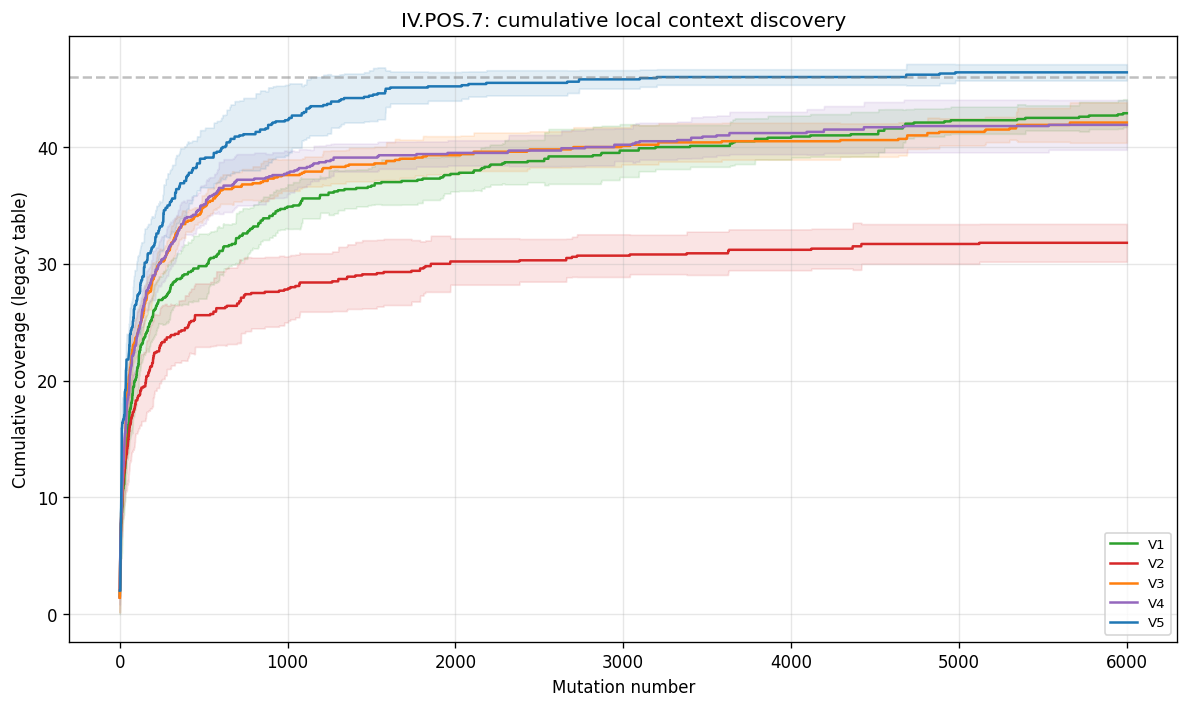

In [4]:

import sqlite3
from analysis.metrics import _coverage_curve, _read_first_hits

m = discover_dbs(IV7 / 'dbs')
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(1, N_MUTATIONS + 1)
for var in VARIANTS:
    curves = []
    for seed, db in sorted(m[var].items()):
        with sqlite3.connect(db) as c:
            hits = _read_first_hits(c)
        curves.append(_coverage_curve(hits, n=N_MUTATIONS))
    arr = np.array(curves)
    mean, sd = arr.mean(0), arr.std(0, ddof=1)
    ax.plot(x, mean, color=COLORS[var], label=f"{var}")
    ax.fill_between(x, mean - sd, mean + sd, color=COLORS[var], alpha=0.12)
ax.axhline(46, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Mutation number'); ax.set_ylabel('Cumulative coverage (legacy table)')
ax.set_title('IV.POS.7: cumulative local context discovery')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
show_plot(fig, PLOTS / '01_cumulative_coverage.png')


## Phase 9.1 — Zone allocation entropy (all variants)


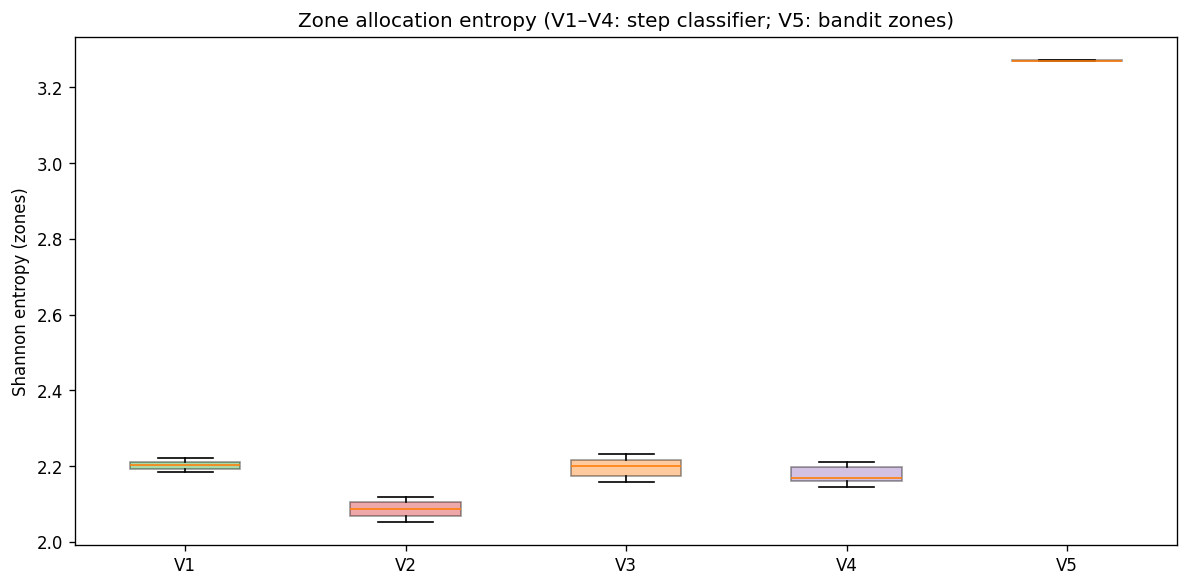

Zone entropy means: {'V1': 2.201806234664476, 'V2': 2.086905268324074, 'V3': 2.1964526106214555, 'V4': 2.175505853565716, 'V5': 3.2712353927071667}


In [5]:

fig, ax = plt.subplots(figsize=(10, 5))
data = [metrics[metrics.variant == v]['allocation_entropy_by_zone'].values for v in VARIANTS]
bp = ax.boxplot(data, tick_labels=VARIANTS, patch_artist=True)
for patch, v in zip(bp['boxes'], VARIANTS):
    patch.set_facecolor(COLORS[v]); patch.set_alpha(0.4)
ax.set_ylabel('Shannon entropy (zones)')
ax.set_title('Zone allocation entropy (V1–V4: step classifier; V5: bandit zones)')
plt.tight_layout()
show_plot(fig, PLOTS / '02_zone_entropy.png')
print('Zone entropy means:', agg.set_index('variant')['allocation_entropy_by_zone_mean'].to_dict())


## Phase 9.1 — local_coverage_v2_final (secondary, Pro §8 granularity)


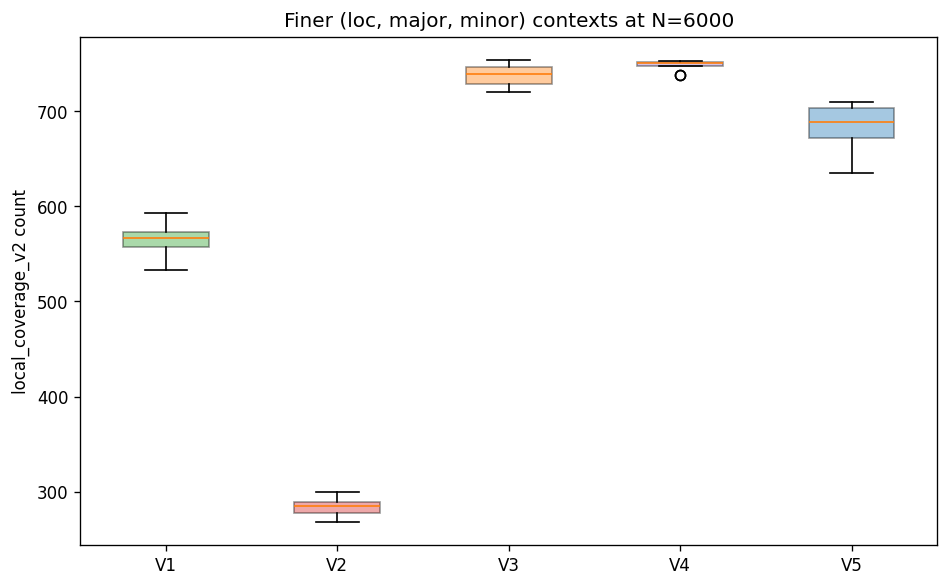

In [6]:

fig, ax = plt.subplots(figsize=(8, 5))
data = [metrics[metrics.variant == v]['local_coverage_v2_final'].values for v in VARIANTS]
bp = ax.boxplot(data, tick_labels=VARIANTS, patch_artist=True)
for patch, v in zip(bp['boxes'], VARIANTS):
    patch.set_facecolor(COLORS[v]); patch.set_alpha(0.4)
ax.set_ylabel('local_coverage_v2 count'); ax.set_title('Finer (loc, major, minor) contexts at N=6000')
plt.tight_layout()
show_plot(fig, PLOTS / '03_local_coverage_v2.png')


## Phase 9.1 — Per-loc v2 depth (wide vs deep)


variant  mean_locs_per_seed  mean_v2_per_common_loc  mean_total_v2
     V1                42.9               13.184149          565.6
     V2                31.8                8.921384          283.7
     V3                42.1               17.683453          737.8
     V4                41.9               17.856802          748.2
     V5                46.4               14.871739          684.5

V5 dominates V1 on breadth, depth-per-common-loc, and total v2.
V3/V4 beat V5 on per-loc depth but miss V5 novel kernel/ECALL locs.


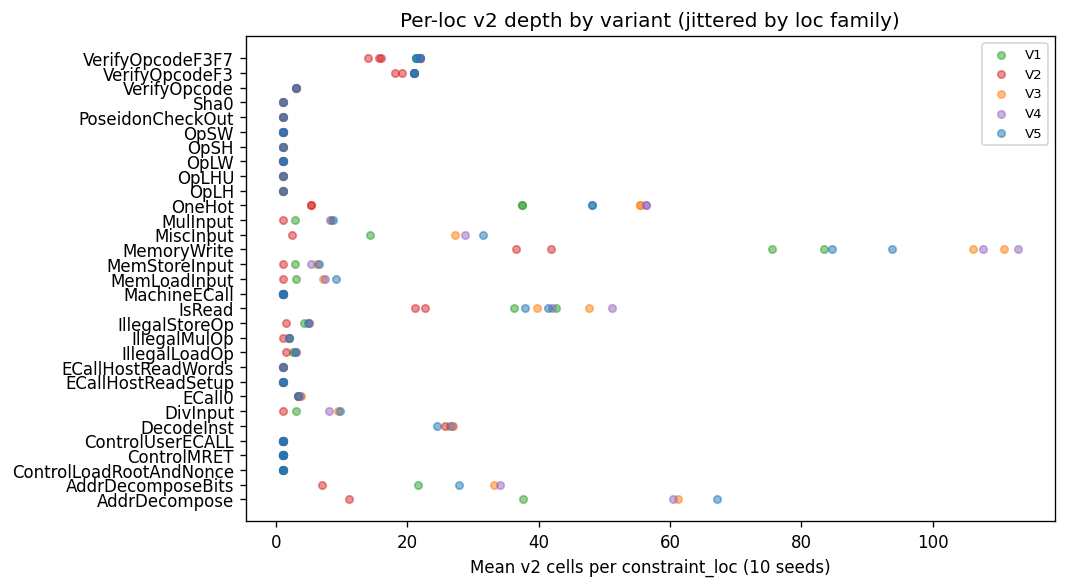

In [7]:

# Fair comparison on V1's 46 common constraint_locs (per_loc_v2_cells_per_seed.csv).
ps = pd.read_csv(IV7 / 'per_loc_v2_cells_per_seed.csv')
v1_locs = set(ps[ps.variant == 'V1']['constraint_loc'])
rows = []
for var in VARIANTS:
    sub = ps[(ps.variant == var) & (ps.constraint_loc.isin(v1_locs))]
    rows.append({
        'variant': var,
        'mean_locs_per_seed': metrics[metrics.variant == var]['local_context_final'].mean(),
        'mean_v2_per_common_loc': sub['v2_cell_count'].mean(),
        'mean_total_v2': metrics[metrics.variant == var]['local_coverage_v2_final'].mean(),
    })
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
print()
print('V5 dominates V1 on breadth, depth-per-common-loc, and total v2.')
print('V3/V4 beat V5 on per-loc depth but miss V5 novel kernel/ECALL locs.')

fig, ax = plt.subplots(figsize=(9, 5))
for var in VARIANTS:
    sub = ploc[ploc.variant == var]
    ax.scatter(sub['mean_v2_cells'], sub['constraint_loc'].str.split('@').str[0],
               alpha=0.5, s=20, color=COLORS[var], label=var)
ax.set_xlabel('Mean v2 cells per constraint_loc (10 seeds)')
ax.set_title('Per-loc v2 depth by variant (jittered by loc family)')
ax.legend(fontsize=8)
plt.tight_layout()
show_plot(fig, PLOTS / '04_per_loc_v2_depth.png')


## Phase 9.2 — Paired tests vs V1


In [8]:

print(paired.to_string(index=False))


variant reference              metric  n_pairs  mean_variant  mean_reference  mean_diff  std_variant  std_reference  variance_ratio  paired_t_stat  paired_t_pvalue  mannwhitney_u  mannwhitney_pvalue
     V2        V1   local_context_AUC       10     177804.00        228142.3  -50338.30 10398.356900    8157.365568        1.274720     -10.038955     3.464261e-06            0.0            0.000183
     V2        V1 local_context_final       10         31.80            42.9     -11.10     1.619328       1.197219        1.352574     -18.943708     1.464437e-08            0.0            0.000165
     V3        V1   local_context_AUC       10     233650.35        228142.3    5508.05  5998.253797    8157.365568        0.735318       1.651312     1.330695e-01           73.0            0.088973
     V3        V1 local_context_final       10         42.10            42.9      -0.80     1.728840       1.197219        1.444047      -1.562267     1.526606e-01           31.5            0.164617
     

## Phase 9.3 — Success criteria (Pro §10)


In [9]:

for var in ['V2','V3','V4','V5']:
    sub = success[success.variant == var]
    passed = sub[sub.passed].criterion_id.tolist()
    print(f"{var}: {len(passed)}/5 PASS — {passed}")


V2: 0/5 PASS — []
V3: 1/5 PASS — ['criterion_5_novel_locs']
V4: 0/5 PASS — []
V5: 5/5 PASS — ['criterion_1_auc_beats_v1', 'criterion_2_final_lower_variance', 'criterion_3_faster_to_43', 'criterion_4_local_and_global', 'criterion_5_novel_locs']


## Phase 9.4 — Discovery rate per kind (IV.POS.5 §17.1 smoking gun)


variant                 V1     V5
kind                             
COMP_OUT_MOD          0.54   4.16
INSTR_TYPE_MOD       30.39  19.89
INSTR_WORD_MOD_FULL   5.83   2.38
INSTR_WORD_MOD_SUR    2.72   1.55
LOAD_VAL_MOD          0.81   0.00
MEM_VAL_MOD          12.60  12.36
PRE_EXEC_REG_MOD      3.71   1.66
STORE_OUT_MOD         0.26   0.00


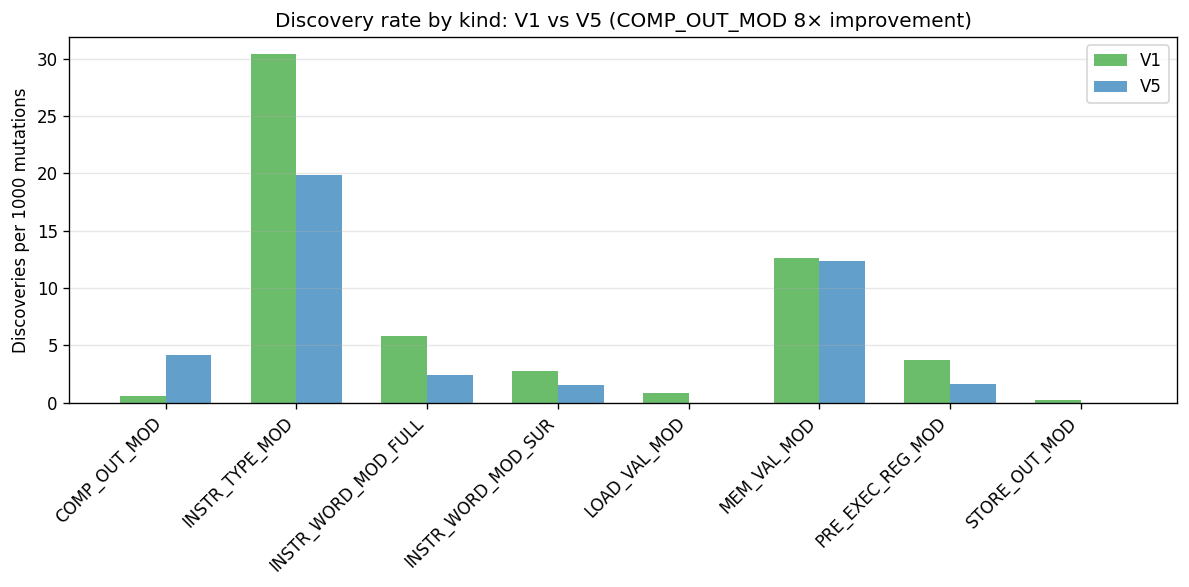

In [10]:

# First-hit credit on coverage.constraint_loc / mutations of that kind / 1000 pulls.
v1v5 = dr[dr.variant.isin(['V1','V5'])].pivot(index='kind', columns='variant', values='discovery_rate_per_1k')
print(v1v5.round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
kinds = dr['kind'].unique()
x = np.arange(len(kinds))
w = 0.35
v1_rates = [dr[(dr.variant=='V1') & (dr.kind==k)]['discovery_rate_per_1k'].iloc[0] for k in kinds]
v5_rates = [dr[(dr.variant=='V5') & (dr.kind==k)]['discovery_rate_per_1k'].iloc[0] for k in kinds]
ax.bar(x - w/2, v1_rates, w, label='V1', color=COLORS['V1'], alpha=0.7)
ax.bar(x + w/2, v5_rates, w, label='V5', color=COLORS['V5'], alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(kinds, rotation=45, ha='right')
ax.set_ylabel('Discoveries per 1000 mutations')
ax.set_title('Discovery rate by kind: V1 vs V5 (COMP_OUT_MOD 8× improvement)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
show_plot(fig, PLOTS / '05_discovery_rate_by_kind.png')


## Phase 9.4 — Counterfactual rewards (Pro §12)


In [11]:

cf = counterfactual_kind_summary(counterfactual_by_kind_frame(IV7 / 'dbs'))
itm = cf[cf.kind == 'INSTR_TYPE_MOD'][['variant','current_reward','discovery_binary_reward']].copy()
for v in itm['variant']:
    sub = cf[cf.variant == v]
    itm.loc[itm.variant==v, 'rank_current'] = int(sub.current_reward.rank(ascending=False)[sub.kind=='INSTR_TYPE_MOD'].iloc[0])
    itm.loc[itm.variant==v, 'rank_discovery'] = int(sub.discovery_binary_reward.rank(ascending=False)[sub.kind=='INSTR_TYPE_MOD'].iloc[0])
print(itm[itm.variant.isin(['V1','V3','V5'])].round(3).to_string(index=False))
print()
print('Allocation, not reward redesign, was the decisive lever for V1/V5 (ITM rank 1 under both).')
print('Discovery rate per kind (previous cell) is the authoritative per-kind diagnostic.')


variant  current_reward  discovery_binary_reward  rank_current  rank_discovery
     V1           0.149                    0.239           1.0             1.0
     V3           0.029                    0.086           1.0             2.0
     V5           0.110                    0.181           1.0             1.0

Allocation, not reward redesign, was the decisive lever for V1/V5 (ITM rank 1 under both).
Discovery rate per kind (previous cell) is the authoritative per-kind diagnostic.


## Phase 9.5 — V5 per-arm mode breakdown


In [12]:

v5 = per_arm_diagnostic_frame(IV7 / 'dbs')
ms = v5_mode_summary(v5['mode_totals'])
print(ms)
print()
print('σ=0 across seeds is expected: cTS_semantic_v2 schedules MODE deterministically')
print('by mutation index (Pro §7.C k-armed floor); seed only randomizes arm within mode.')
top = v5['cumulative_reward_by_arm'].groupby('arm_id')['cumulative_reward'].mean().sort_values(ascending=False).head(10)
print('Top arms by mean cumulative reward:')
print(top)


        mode  mean_pulls_per_seed  std_pulls  total_pulls
0   adaptive                233.0        0.0         2330
1       cold                144.0        0.0         1440
2      floor               5615.0        0.0        56150
3  singleton                  8.0        0.0           80

σ=0 across seeds is expected: cTS_semantic_v2 schedules MODE deterministically
by mutation index (Pro §7.C k-armed floor); seed only randomizes arm within mode.
Top arms by mean cumulative reward:
arm_id
MEM_VAL_MOD|last_step                    30.654788
INSTR_WORD_MOD_SUR|core_memory_store     23.638746
INSTR_WORD_MOD_SUR|core_memory_load      23.327380
INSTR_WORD_MOD_SUR|core_arithmetic       22.451699
INSTR_WORD_MOD_SUR|kernel_other          22.324936
INSTR_WORD_MOD_FULL|core_memory_store    21.656231
INSTR_WORD_MOD_FULL|core_memory_load     21.359537
INSTR_WORD_MOD_SUR|core_mul              21.288734
INSTR_WORD_MOD_SUR|post_ecall            21.011552
INSTR_WORD_MOD_SUR|core_shr              20.63

## Summary placeholder (D1 §7 — human-authored, not Composer)


In [13]:

print('Headline: V5 — 4 novel contexts + 5/5 criteria + 4.3× speedup to 43 (p<1e-4).')
print('See success_criteria.csv, v5_novel_contexts.json, discovery_rate_by_kind.csv.')
print('Do NOT treat this cell as D1 conclusion text.')


Headline: V5 — 4 novel contexts + 5/5 criteria + 4.3× speedup to 43 (p<1e-4).
See success_criteria.csv, v5_novel_contexts.json, discovery_rate_by_kind.csv.
Do NOT treat this cell as D1 conclusion text.
